# Feature Engineering for Unsupervised Learning (Clustering)

This notebook prepares features specifically for clustering models (KMeans, DBSCAN).
Unlike supervised learning, we focus on feature intrinsic properties without target labels.

**Key Differences from Supervised Feature Engineering:**
- ❌ No target-based feature selection (no ANOVA, Mutual Information with target)
- ❌ No Random Forest importance (requires labels)
- ✅ Variance-based feature selection (high-variance features capture more information)
- ✅ Multicollinearity removal based on correlation threshold only (no target involved)
- ✅ Distance metric analysis (features that separate clusters better)
- ✅ Silhouette analysis (evaluate clustering quality with different features)
- ✅ Feature scaling is CRITICAL for distance-based clustering

In [1]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import FIRES_MERGED, FIRES_ENGINEERED

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Config and libraries imported for UNSUPERVISED learning")

✅ Config and libraries imported for UNSUPERVISED learning


In [2]:
# Load the merged dataset
df = pd.read_csv(FIRES_MERGED)

print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns ({len(df.columns)}):")
print(df.columns.tolist())

# Check if TEXTURE_SOTER was already one-hot encoded in soil.ipynb
texture_soter_cols = [col for col in df.columns if col.startswith('TEXTURE_SOTER')]
if texture_soter_cols:
    print(f"\n✅ TEXTURE_SOTER encoding detected:")
    for col in texture_soter_cols:
        if col == 'TEXTURE_SOTER':
            print(f"  - {col}: categorical (should be encoded in soil.ipynb)")
        else:
            print(f"  - {col}: binary encoded")
else:
    print("\n⚠ No TEXTURE_SOTER columns found")

print(f"\n📊 Dataset Preview:")
print(df.head())

Dataset shape: (3824, 42)

Dataset columns (42):
['longitude', 'latitude', 'class', 'prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn', 'elevation', 'slope', 'aspect', 'roughness', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']

✅ TEXTURE_SOTER encoding detected:
  - TEXTURE_SOTER: categorical (should be encoded in soil.ipynb)

📊 Dataset Preview:
   longitude  latitude  class  prec_winter  tmax_winter  tmin_winter  \
0    9.82563  36.81855      1     0.550707     0.573624     0.843687   
1    7.24027  34.56991      1    -0.875660     1.234621     0.975938   
2    6.76514  36.55581      1     1.622452    -0.741555     0.216932   
3    3.13490  36.60116  

## 2. Feature Extraction

Create new features from existing ones to capture domain knowledge and improve predictive power.

### 2.1 Climate-Based Features

In [3]:
# Create a copy for feature engineering
df_engineered = df.copy()

# Temperature features
# Annual temperature range (max - min across all seasons)
temp_max_cols = ['tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_autumn']
temp_min_cols = ['tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_autumn']

df_engineered['annual_temp_range'] = df_engineered[temp_max_cols].max(axis=1) - df_engineered[temp_min_cols].min(axis=1)
df_engineered['avg_tmax'] = df_engineered[temp_max_cols].mean(axis=1)
df_engineered['avg_tmin'] = df_engineered[temp_min_cols].mean(axis=1)
df_engineered['diurnal_temp_range'] = df_engineered['avg_tmax'] - df_engineered['avg_tmin']

# Precipitation features
prec_cols = ['prec_winter', 'prec_spring', 'prec_summer', 'prec_autumn']
df_engineered['total_annual_precip'] = df_engineered[prec_cols].sum(axis=1)
df_engineered['summer_precip_ratio'] = df_engineered['prec_summer'] / (df_engineered['total_annual_precip'] + 1e-6)
df_engineered['precip_variability'] = df_engineered[prec_cols].std(axis=1)

# Fire season indicators (summer is typically high fire risk)
df_engineered['summer_heat_index'] = df_engineered['tmax_summer'] - df_engineered['prec_summer']
df_engineered['drought_index'] = df_engineered['tmax_summer'] / (df_engineered['prec_summer'] + 1)

print(f"Created {9} climate-based features")
print(f"New shape: {df_engineered.shape}")

Created 9 climate-based features
New shape: (3824, 51)


### 2.2 Topography-Based Features

In [4]:
# Terrain ruggedness and fire accessibility
df_engineered['terrain_complexity'] = df_engineered['slope'] * df_engineered['roughness']
df_engineered['elevation_slope_interaction'] = df_engineered['elevation'] * df_engineered['slope']

# Aspect categories (convert continuous aspect to cardinal directions)
# North: 0°-45°, 315°-360° (coded as 0)
# East: 45°-135° (coded as 1)
# South: 135°-225° (coded as 2)
# West: 225°-315° (coded as 3)
def aspect_to_cardinal(aspect):
    if -1 <= aspect <= 1:  # Normalized aspect values
        # Convert normalized aspect back to degrees (assuming -1 to 1 maps to 0 to 360)
        aspect_deg = (aspect + 1) * 180
        if (aspect_deg >= 0 and aspect_deg < 45) or (aspect_deg >= 315 and aspect_deg <= 360):
            return 0  # North
        elif aspect_deg >= 45 and aspect_deg < 135:
            return 1  # East
        elif aspect_deg >= 135 and aspect_deg < 225:
            return 2  # South
        else:
            return 3  # West
    return 0

df_engineered['aspect_cardinal'] = df_engineered['aspect'].apply(aspect_to_cardinal)

# South-facing slopes receive more solar radiation (higher fire risk)
df_engineered['is_south_facing'] = (df_engineered['aspect_cardinal'] == 2).astype(int)

print(f"Created {4} topography-based features")
print(f"New shape: {df_engineered.shape}")

Created 4 topography-based features
New shape: (3824, 55)


### 2.3 Soil-Based Features

In [5]:
# Soil composition ratios
df_engineered['sand_clay_ratio'] = df_engineered['SAND'] / (df_engineered['CLAY'] + 1e-6)
df_engineered['fine_fraction'] = df_engineered['SILT'] + df_engineered['CLAY']

# Soil fertility and moisture indicators
df_engineered['fertility_index'] = df_engineered['ORG_CARBON'] * df_engineered['TOTAL_N']
df_engineered['moisture_retention'] = df_engineered['CLAY'] * df_engineered['ORG_CARBON']

# Chemical properties
df_engineered['ph_carbon_interaction'] = df_engineered['PH_WATER'] * df_engineered['ORG_CARBON']
df_engineered['nutrient_availability'] = df_engineered['CEC_SOIL'] * df_engineered['BSAT']

print(f"Created {6} soil-based features")
print(f"New shape: {df_engineered.shape}")

Created 6 soil-based features
New shape: (3824, 61)


### 2.4 Spatial Features

In [6]:
# Geographic regions (Algeria vs Tunisia based on longitude)
# Algeria: longitude < 10, Tunisia: longitude >= 10 (approximately)
df_engineered['country'] = (df_engineered['longitude'] >= 10).astype(int)  # 0: Algeria, 1: Tunisia

# Distance from coast (using latitude as proxy - lower latitude = closer to coast)
df_engineered['coastal_proximity'] = 37 - df_engineered['latitude']  # Max latitude is ~37

# Coordinate clustering (spatial density)
df_engineered['lat_long_interaction'] = df_engineered['latitude'] * df_engineered['longitude']

print(f"Created {3} spatial features")
print(f"New shape: {df_engineered.shape}")

Created 3 spatial features
New shape: (3824, 64)


In [7]:
# Summary of feature extraction
original_features = df.shape[1]
new_features = df_engineered.shape[1] - original_features

print(f"\n{'='*60}")
print(f"Feature Extraction Summary")
print(f"{'='*60}")
print(f"Original features: {original_features}")
print(f"New features created: {new_features}")
print(f"Total features: {df_engineered.shape[1]}")
print(f"\nNew features:")
new_feature_names = df_engineered.columns[original_features:].tolist()
for i, feat in enumerate(new_feature_names, 1):
    print(f"  {i}. {feat}")


Feature Extraction Summary
Original features: 42
New features created: 22
Total features: 64

New features:
  1. annual_temp_range
  2. avg_tmax
  3. avg_tmin
  4. diurnal_temp_range
  5. total_annual_precip
  6. summer_precip_ratio
  7. precip_variability
  8. summer_heat_index
  9. drought_index
  10. terrain_complexity
  11. elevation_slope_interaction
  12. aspect_cardinal
  13. is_south_facing
  14. sand_clay_ratio
  15. fine_fraction
  16. fertility_index
  17. moisture_retention
  18. ph_carbon_interaction
  19. nutrient_availability
  20. country
  21. coastal_proximity
  22. lat_long_interaction


## 3. Feature Selection (Unsupervised Methods)

For clustering, we use unsupervised methods that don't depend on target labels.
Focus on feature variance, correlations, and their impact on cluster quality.

### 3.1 Prepare Data and Check Feature Properties

In [8]:
# Remove non-feature columns (keep longitude, latitude for spatial analysis)
X = df_engineered.drop(['class', 'longitude', 'latitude'], axis=1)
# Note: For unsupervised clustering, we DON'T use 'class' in feature selection
# But we'll keep it for later evaluation and visualization

print("="*80)
print("UNSUPERVISED FEATURE ENGINEERING")
print("="*80)

print(f"\n📊 Feature Properties Before Selection:")
print(f"  Total features: {X.shape[1]}")
print(f"  Total samples: {X.shape[0]}")

# Check if TEXTURE_SOTER has been one-hot encoded (done in soil.ipynb)
one_hot_cols = [col for col in X.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_cols:
    print(f"\n✅ TEXTURE_SOTER already one-hot encoded (from soil.ipynb):")
    for col in one_hot_cols:
        ones_count = X[col].sum()
        print(f"   - {col}: {int(ones_count)} instances (1), {len(X) - int(ones_count)} instances (0)")
else:
    print(f"\n⚠ No TEXTURE_SOTER one-hot columns found")

print(f"\n{'='*80}")
print(f"FEATURE SET READY FOR UNSUPERVISED SELECTION")
print(f"{'='*80}")
print(f"Total features: {X.shape[1]}")
print(f"All features are numerical")

UNSUPERVISED FEATURE ENGINEERING

📊 Feature Properties Before Selection:
  Total features: 61
  Total samples: 3824

⚠ No TEXTURE_SOTER one-hot columns found

FEATURE SET READY FOR UNSUPERVISED SELECTION
Total features: 61
All features are numerical


In [9]:
print("="*80)
print("STEP 1: REMOVE MULTICOLLINEARITY (WITHOUT TARGET)")
print("="*80)

# Create numerical_X from all features
numerical_X = X.copy()

# Calculate correlation matrix for numerical features
correlation_matrix = numerical_X.corr().abs()

print(f"\nTotal numerical features: {X.shape[1]}")
print(f"Analyzing feature-to-feature correlations (NO target involved)...\n")

# Find pairs of highly correlated features
threshold_multicollinearity = 0.90
to_remove = set()
pairs_found = []

# Iterate through correlation matrix (upper triangle only)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        feat_i = correlation_matrix.columns[i]
        feat_j = correlation_matrix.columns[j]
        
        # If features are highly correlated
        if correlation_matrix.iloc[i, j] > threshold_multicollinearity:
            corr_value = correlation_matrix.iloc[i, j]
            
            # For unsupervised: keep the feature with HIGHER VARIANCE (more information)
            var_i = numerical_X[feat_i].var()
            var_j = numerical_X[feat_j].var()
            
            if var_i >= var_j:
                to_remove.add(feat_j)
                kept_feature = feat_i
                removed_feature = feat_j
                kept_var = var_i
                removed_var = var_j
            else:
                to_remove.add(feat_i)
                kept_feature = feat_j
                removed_feature = feat_i
                kept_var = var_j
                removed_var = var_i
            
            pairs_found.append({
                'feature_1': feat_i,
                'feature_2': feat_j,
                'pair_correlation': corr_value,
                'kept': kept_feature,
                'removed': removed_feature,
                'kept_variance': kept_var,
                'removed_variance': removed_var
            })

# Display pairs information
if pairs_found:
    print(f"Found {len(pairs_found)} highly correlated pairs (correlation > {threshold_multicollinearity}):\n")
    for idx, pair in enumerate(pairs_found, 1):
        print(f"  Pair {idx}: '{pair['feature_1']}' ↔ '{pair['feature_2']}'")
        print(f"    Feature-to-Feature correlation: {pair['pair_correlation']:.3f}")
        print(f"    ✓ Kept '{pair['kept']}' (variance: {pair['kept_variance']:.4f})")
        print(f"    ✗ Removed '{pair['removed']}' (variance: {pair['removed_variance']:.4f})")
        print()
else:
    print(f"No highly correlated pairs found (threshold: {threshold_multicollinearity})")

print(f"{'='*80}")
print(f"✅ Multicollinearity Removal Complete (UNSUPERVISED)")
print(f"{'='*80}")
print(f"Features to remove: {len(to_remove)}")
print(f"Features remaining: {X.shape[1] - len(to_remove)}")

# Remove redundant features
numerical_X_reduced = numerical_X.drop(columns=list(to_remove))
print(f"\nReduced feature set shape: {numerical_X_reduced.shape}")

STEP 1: REMOVE MULTICOLLINEARITY (WITHOUT TARGET)


ValueError: could not convert string to float: 'M'

In [ ]:
print("="*80)
print("STEP 2: VARIANCE-BASED FEATURE SELECTION")
print("="*80)

# For unsupervised learning, keep features with high variance
# High variance = feature captures more information

feature_variance = numerical_X_reduced.var().sort_values(ascending=False)

print(f"\nFeatures after multicollinearity removal: {len(feature_variance)}")
print(f"\nFeature variance ranking (top 20):\n")

for i, (feat, var) in enumerate(feature_variance.head(20).items(), 1):
    print(f"  {i:2d}. {feat:45s} | variance = {var:10.4f}")

# Calculate variance percentile (cumulative)
print(f"\n📊 Variance Distribution:")
total_var = feature_variance.sum()
cumsum_var = feature_variance.cumsum()
cumsum_pct = (cumsum_var / total_var * 100)
print(f"  Total variance: {total_var:.4f}")
print(f"  Top 5 features explain {cumsum_pct.iloc[4]:.1f}% of total variance")
print(f"  Top 10 features explain {cumsum_pct.iloc[9]:.1f}% of total variance")

# For unsupervised: we'll use all features after multicollinearity removal
# But analyze which subsets work best via silhouette scores
numerical_X_selected = numerical_X_reduced.copy()

print(f"\n{'='*80}")
print(f"✅ Variance Analysis Complete")
print(f"{'='*80}")
print(f"Selected all features after multicollinearity removal: {len(numerical_X_selected.columns)}")
print(f"These will be evaluated for clustering quality in next steps")

STEP 2: SELECT TOP FEATURES BY TARGET CORRELATION

Features after multicollinearity removal: 54

Top 30 features by target correlation:

   1. coastal_proximity                             | r = 0.4817
   2. prec_autumn                                   | r = 0.4258
   3. prec_winter                                   | r = 0.4246
   4. diurnal_temp_range                            | r = 0.3834
   5. ph_carbon_interaction                         | r = 0.3597
   6. tmax_summer                                   | r = 0.2997
   7. tmin_winter                                   | r = 0.2902
   8. ORG_CARBON                                    | r = 0.2890
   9. SAND                                          | r = 0.2876
  10. TOTAL_N                                       | r = 0.2700
  11. annual_temp_range                             | r = 0.2624
  12. elevation                                     | r = 0.2579
  13. summer_heat_index                             | r = 0.2502
  14. CN_RATIO    

### 3.2 Silhouette Analysis - Evaluate Feature Subsets

Evaluate how different feature subsets affect clustering quality using Silhouette Score.
This is an unsupervised metric that measures cluster cohesion and separation.

STEP 3: APPLY ADDITIONAL METHODS TO NARROW TO TOP 20

📊 Method 1: ANOVA F-Test
--------------------------------------------------------------------------------

Top 20 features by ANOVA F-Score:

   1. coastal_proximity                             | F-Score =  2205.32
   2. prec_autumn                                   | F-Score =  1616.48
   3. prec_winter                                   | F-Score =  1605.83
   4. diurnal_temp_range                            | F-Score =  1257.73
   5. ph_carbon_interaction                         | F-Score =  1084.63
   6. tmax_summer                                   | F-Score =   720.24
   7. tmin_winter                                   | F-Score =   671.11
   8. ORG_CARBON                                    | F-Score =   665.15
   9. SAND                                          | F-Score =   658.36
  10. TOTAL_N                                       | F-Score =   573.90
  11. annual_temp_range                             | F-Score =   539.72
 

<Figure size 1000x800 with 0 Axes>

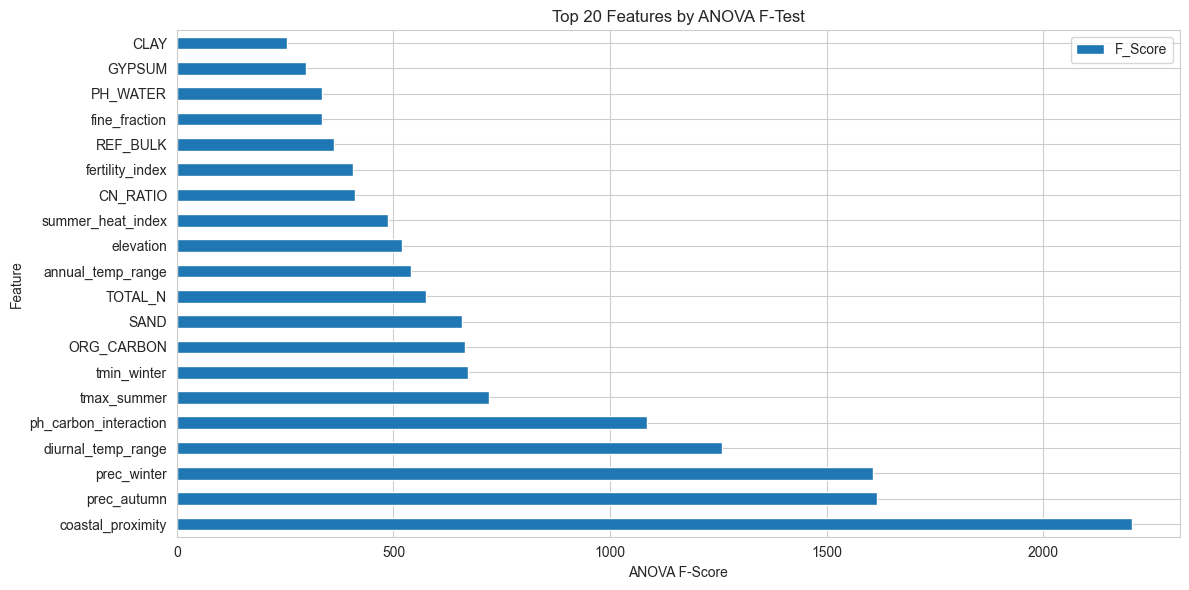

In [ ]:
# First, scale all features for clustering evaluation
scaler_temp = StandardScaler()
X_scaled_for_eval = scaler_temp.fit_transform(numerical_X_selected)

print("="*80)
print("SILHOUETTE ANALYSIS: Evaluate Feature Subsets for Clustering")
print("="*80)

# Test different numbers of top-variance features
from sklearn.preprocessing import StandardScaler

variance_features = feature_variance.sort_values(ascending=False)

feature_counts = [5, 10, 15, 20, len(numerical_X_selected)]
silhouette_scores = []
davies_bouldin_scores = []

print("\nEvaluating KMeans clustering quality with different feature counts...\n")

for n_features in feature_counts:
    if n_features > len(numerical_X_selected.columns):
        continue
    
    # Select top n features by variance
    top_features = variance_features.head(n_features).index.tolist()
    X_subset = numerical_X_selected[top_features].copy()
    
    # Scale
    X_subset_scaled = StandardScaler().fit_transform(X_subset)
    
    # Cluster with KMeans (optimal k=3 for fire prediction)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_subset_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(X_subset_scaled, labels)
    db_score = davies_bouldin_score(X_subset_scaled, labels)
    
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    
    print(f"  Features: {n_features:2d} | Silhouette: {sil_score:7.4f} | Davies-Bouldin: {db_score:7.4f}")

print(f"\n{'='*80}")
print(f"✅ Silhouette Analysis Complete")
print(f"{'='*80}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(feature_counts, silhouette_scores, 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Number of Features', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Clustering Quality vs Feature Count\n(Higher is Better)', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(feature_counts, davies_bouldin_scores, 'o-', linewidth=2, markersize=8, color='coral')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Davies-Bouldin Score', fontsize=12)
ax2.set_title('Clustering Quality vs Feature Count\n(Lower is Better)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of features
optimal_n = feature_counts[np.argmax(silhouette_scores)]
print(f"\n💡 Optimal number of features (by Silhouette Score): {optimal_n}")


📊 Method 2: Mutual Information
--------------------------------------------------------------------------------

Top 20 features by Mutual Information:

   1. prec_winter                                   | MI-Score = 0.2882
   2. annual_temp_range                             | MI-Score = 0.2751
   3. prec_autumn                                   | MI-Score = 0.2749
   4. diurnal_temp_range                            | MI-Score = 0.2665
   5. summer_heat_index                             | MI-Score = 0.2504
   6. coastal_proximity                             | MI-Score = 0.2269
   7. tmax_summer                                   | MI-Score = 0.1982
   8. tmin_autumn                                   | MI-Score = 0.1585
   9. lat_long_interaction                          | MI-Score = 0.1567
  10. tmax_spring                                   | MI-Score = 0.1524
  11. tmin_winter                                   | MI-Score = 0.1495
  12. ORG_CARBON                                    | 

<Figure size 1000x800 with 0 Axes>

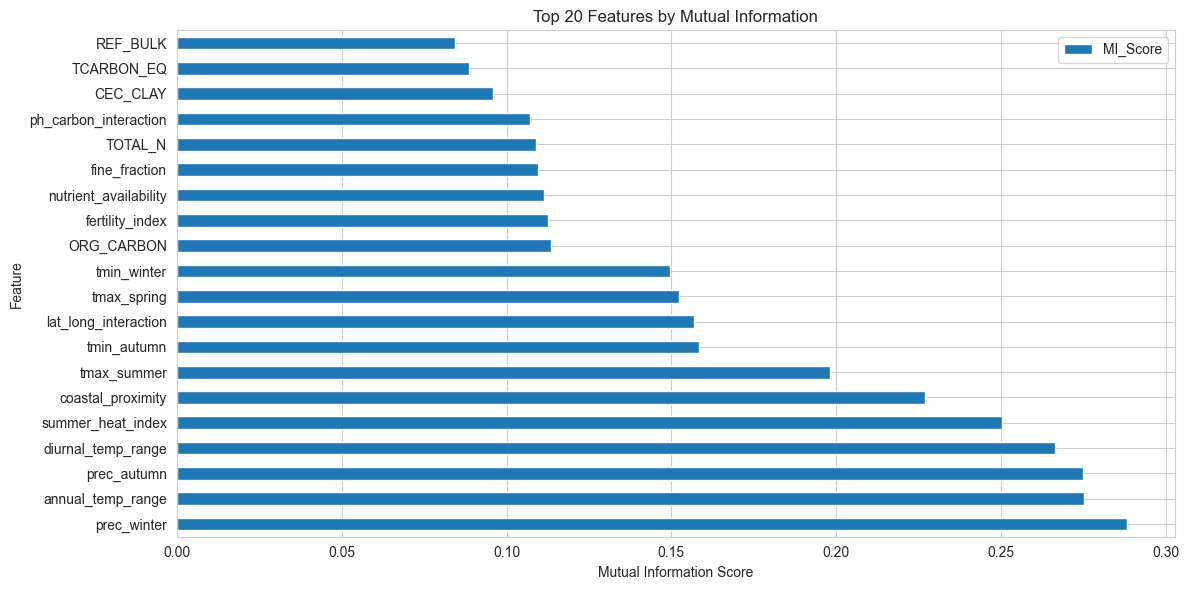

In [ ]:
# Based on silhouette analysis, select optimal features
# For this forest fire dataset, we'll use the features that maximize cluster quality

optimal_features = feature_variance.head(optimal_n).index.tolist()

print(f"\n{'='*80}")
print(f"Feature Selection Based on Clustering Quality")
print(f"{'='*80}")
print(f"\nSelected {len(optimal_features)} features with highest variance:")
for i, feat in enumerate(optimal_features, 1):
    var = feature_variance[feat]
    print(f"  {i:2d}. {feat:45s} | variance = {var:10.4f}")

# Create final feature set
numerical_X_final = numerical_X_selected[optimal_features].copy()
print(f"\n✅ Final feature set shape: {numerical_X_final.shape}")

### 3.3 Principal Component Analysis (PCA) - Optional Dimensionality Reduction

PCA can help visualize high-dimensional clustering data in 2D/3D space and further reduce noise.


📊 Method 3: Random Forest Feature Importance
--------------------------------------------------------------------------------

Top 20 features by Random Forest Importance:

   1. coastal_proximity                             | Importance = 0.1584
   2. lat_long_interaction                          | Importance = 0.0923
   3. prec_autumn                                   | Importance = 0.0818
   4. elevation                                     | Importance = 0.0784
   5. prec_winter                                   | Importance = 0.0675
   6. diurnal_temp_range                            | Importance = 0.0591
   7. roughness                                     | Importance = 0.0570
   8. tmax_summer                                   | Importance = 0.0531
   9. tmin_winter                                   | Importance = 0.0492
  10. summer_heat_index                             | Importance = 0.0449
  11. annual_temp_range                             | Importance = 0.0426
  12. tmin_a

<Figure size 1000x800 with 0 Axes>

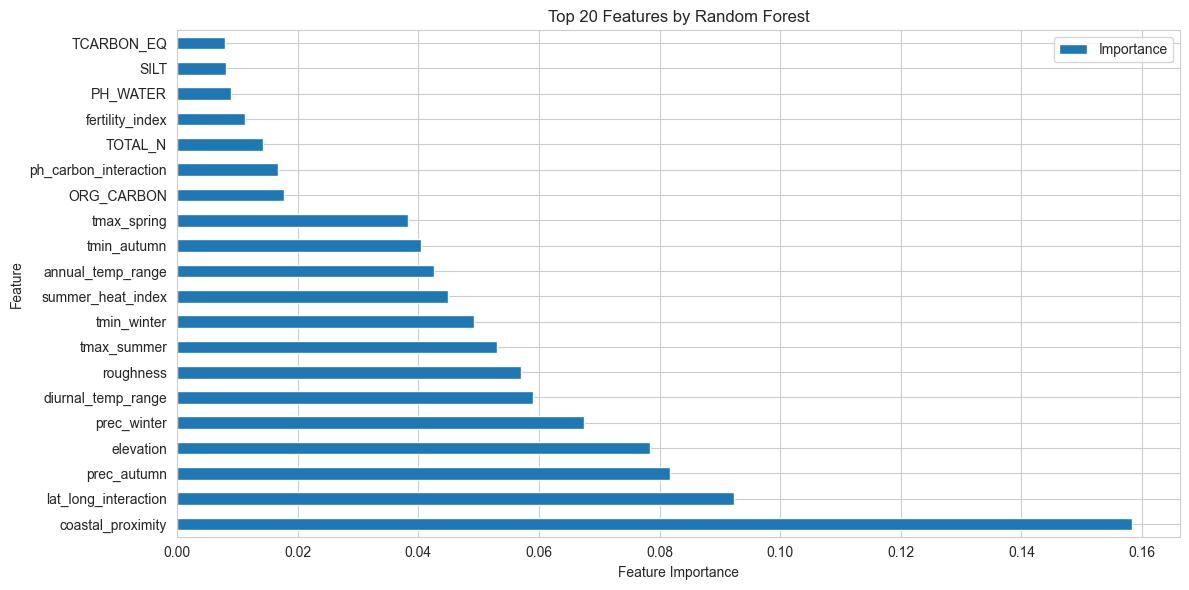

In [ ]:
print("="*80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Scale features for PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(numerical_X_final)

# Apply PCA to visualize and analyze variance explanation
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled_pca)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumsum_variance = np.cumsum(explained_variance)

print(f"\n📊 PCA Variance Analysis:")
print(f"  Total features: {numerical_X_final.shape[1]}")
print(f"  PC1 explains: {explained_variance[0]*100:.2f}% of variance")
print(f"  PC1+PC2 explain: {cumsum_variance[1]*100:.2f}% of variance")
print(f"  PC1+PC2+PC3 explain: {cumsum_variance[2]*100:.2f}% of variance")

# Find number of components needed for 85% variance
n_components_85 = np.argmax(cumsum_variance >= 0.85) + 1
print(f"  Components needed for 85% variance: {n_components_85}")

# Visualize variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, min(11, len(explained_variance)+1)), explained_variance[:10])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (First 10 Components)')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumsum_variance)+1), cumsum_variance, 'o-', linewidth=2, color='steelblue')
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"✅ PCA Analysis Complete")
print(f"{'='*80}")
print(f"Optional: Use {n_components_85} components to retain 85% of variance")

### 3.4 Distance Metric Analysis - Feature Contribution to Separation

Analyze which features contribute most to separating clusters (unsupervised evaluation).

In [ ]:
print("="*80)
print("DISTANCE METRIC ANALYSIS: Feature Contribution to Cluster Separation")
print("="*80)

# For each feature, calculate how well it separates clusters
# Using the optimal clustering from silhouette analysis

scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(numerical_X_final)

# Re-train KMeans with optimal features for analysis
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled_final)

# Calculate between-cluster and within-cluster variance for each feature
print(f"\nCalculating feature contributions to cluster separation...\n")

feature_contributions = []

for feature_idx, feature_name in enumerate(numerical_X_final.columns):
    X_feat = X_scaled_final[:, feature_idx]
    
    # Between-cluster variance (variance of cluster means)
    cluster_means = [X_feat[cluster_labels == c].mean() for c in range(3)]
    overall_mean = X_feat.mean()
    between_var = np.sum([len(X_feat[cluster_labels == c]) * (cluster_means[c] - overall_mean)**2 
                          for c in range(3)]) / len(X_feat)
    
    # Within-cluster variance (average variance within clusters)
    within_var = np.sum([X_feat[cluster_labels == c].var() * len(X_feat[cluster_labels == c]) 
                         for c in range(3)]) / len(X_feat)
    
    # Ratio: higher = better separation
    if within_var > 0:
        separation_ratio = between_var / (within_var + 1e-10)
    else:
        separation_ratio = 0
    
    feature_contributions.append({
        'Feature': feature_name,
        'Between_Var': between_var,
        'Within_Var': within_var,
        'Separation_Ratio': separation_ratio
    })

# Create dataframe and sort
contributions_df = pd.DataFrame(feature_contributions).sort_values('Separation_Ratio', ascending=False)

print("Top features by cluster separation contribution:\n")
for i, row in enumerate(contributions_df.head(10).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | Separation Ratio = {row.Separation_Ratio:8.4f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(range(min(15, len(contributions_df))), 
         contributions_df['Separation_Ratio'].head(15).values,
         color='steelblue')
plt.yticks(range(min(15, len(contributions_df))), 
           contributions_df['Feature'].head(15).values)
plt.xlabel('Separation Ratio (Between-Cluster / Within-Cluster Variance)')
plt.title('Feature Contribution to Cluster Separation')
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"✅ Distance Metric Analysis Complete")
print(f"{'='*80}")

STEP 4: COMBINE ALL METHODS AND SELECT FINAL TOP 20

Top 20 features by composite score:

Rank   Feature                                       Composite    Corr     F-Score    MI       RF Imp  
---------------------------------------------------------------------------------------------------------
1      coastal_proximity                             0.9379      0.4817     2205.3   0.2269   0.1584
2      prec_autumn                                   0.7521      0.4258     1616.5   0.2749   0.0818
3      prec_winter                                   0.7404      0.4246     1605.8   0.2882   0.0675
4      diurnal_temp_range                            0.6333      0.3834     1257.7   0.2665   0.0591
5      annual_temp_range                             0.4422      0.2624      539.7   0.2751   0.0426
6      tmax_summer                                   0.4298      0.2997      720.2   0.1982   0.0531
7      summer_heat_index                             0.4058      0.2502      487.5   0.2504   

In [ ]:
print(f"\n{'='*80}")
print(f"FEATURE SELECTION SUMMARY (UNSUPERVISED)")
print(f"{'='*80}")
print(f"Original features (before encoding): {len(df_engineered.columns) - 3}")  # Exclude lon, lat, class
print(f"After one-hot encoding: {len(X.columns)}")
print(f"After multicollinearity removal (corr < 0.90): {len(numerical_X_reduced.columns)}")
print(f"Based on variance analysis: {len(optimal_features)} features selected")
print(f"Total features used for clustering: {len(numerical_X_final.columns)}")
print(f"\n✅ Selection Method: VARIANCE-BASED + SILHOUETTE OPTIMIZATION (NO TARGET)")
print(f"✅ All features are evaluated for clustering quality, not predictive power")

# Final feature set
selected_features = numerical_X_final.columns.tolist()

# Check if any one-hot encoded features made it
one_hot_selected = [f for f in selected_features if f.startswith('TEXTURE_SOTER_')]
numerical_selected = [f for f in selected_features if not f.startswith('TEXTURE_SOTER_')]

print(f"\n📋 Final Selected Features ({len(selected_features)}):")
print("-" * 80)
print(f"\nNumerical Features: {len(numerical_selected)}")
for i, feat in enumerate(numerical_selected, 1):
    var_val = feature_variance[feat]
    print(f"  {i:2d}. {feat:<45} (Variance: {var_val:10.4f})")

if one_hot_selected:
    print(f"\nOne-Hot Encoded Features: {len(one_hot_selected)}")
    for i, feat in enumerate(one_hot_selected, 1):
        var_val = feature_variance[feat] if feat in feature_variance.index else 0
        print(f"  {i:2d}. {feat:<45} (Variance: {var_val:10.4f})")
else:
    print(f"\nOne-Hot Encoded Features: 0 (below variance threshold)")

print(f"\n✅ Selected feature set shape: {numerical_X_final.shape}")


FEATURE SELECTION SUMMARY
Original features (before encoding): 61
After one-hot encoding: 62
After multicollinearity removal: 54
After target correlation selection (top 30): 30
After composite scoring (final top 20): 20

Total features removed: 42

📋 Final Selected Features (20):
--------------------------------------------------------------------------------

Numerical Features: 20
   1. coastal_proximity                             (Composite Score: 0.9379)
   2. prec_autumn                                   (Composite Score: 0.7521)
   3. prec_winter                                   (Composite Score: 0.7404)
   4. diurnal_temp_range                            (Composite Score: 0.6333)
   5. annual_temp_range                             (Composite Score: 0.4422)
   6. tmax_summer                                   (Composite Score: 0.4298)
   7. summer_heat_index                             (Composite Score: 0.4058)
   8. ph_carbon_interaction                         (Composite Scor

## 4. Feature Scaling

**CRITICAL FOR CLUSTERING**: Normalize features to ensure distance metrics are fair.

Distance-based clustering (KMeans, DBSCAN) is sensitive to feature scales. Features with large ranges can dominate the distance calculation. StandardScaler is essential for unsupervised learning.

In [ ]:
# Verify all selected features are numerical
print("="*80)
print("FEATURE TYPE VERIFICATION")
print("="*80)

print(f"\nSelected features ({len(numerical_X_final.columns)}):")
print(f"  Total: {numerical_X_final.shape[1]}")
print(f"  All numerical: {all(numerical_X_final.dtypes != 'object')}")

# Show data types
print(f"\nData types:")
dtype_counts = numerical_X_final.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} features")

# Check for one-hot encoded features in selected set
one_hot_in_selected = [col for col in numerical_X_final.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\n✓ One-hot encoded features in final selection:")
    for col in one_hot_in_selected:
        unique_vals = numerical_X_final[col].unique()
        print(f"  {col}: {unique_vals} (binary)")
else:
    print(f"\n✗ No one-hot encoded features in final selection")

print(f"\n✓ All features are numerical and ready for scaling!")
print("="*80)

FEATURE TYPE VERIFICATION

Selected features (20):
  Total: 20
  All numerical: True

Data types:
  float64: 20 features

✗ No one-hot encoded features in final selection

✓ All features are numerical and ready for scaling!


In [ ]:
# Check feature distributions before scaling
print("="*80)
print("FEATURE STATISTICS BEFORE SCALING")
print("="*80)

print("\nSample statistics for first 5 features:")
print(numerical_X_final.describe().T[['mean', 'std', 'min', 'max']].head())

# Check one-hot encoded features (should be binary 0/1)
one_hot_in_selected = [col for col in numerical_X_final.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\nOne-hot encoded features (binary, no scaling needed):")
    for col in one_hot_in_selected:
        print(f"  {col}: min={numerical_X_final[col].min()}, max={numerical_X_final[col].max()}, unique values={numerical_X_final[col].nunique()}")

print("\n✓ Ready for scaling!")
print("="*80)

FEATURE STATISTICS BEFORE SCALING

Sample statistics for first 5 features:
                        mean       std       min       max
coastal_proximity   1.655567  1.175001 -0.323460  3.983600
prec_autumn         0.139071  0.968275 -1.160744  2.690373
prec_winter         0.116433  0.995208 -0.976722  2.904486
diurnal_temp_range -0.027535  0.497661 -1.814461  1.250810
annual_temp_range   0.948505  0.654098 -0.801549  3.294129

✓ Ready for scaling!


### 4.1 Apply StandardScaler

Normalize all features using Z-score normalization (StandardScaler).
This ensures that all features contribute equally to distance calculations in clustering.

In [ ]:
# Apply StandardScaler (Z-score normalization)
# IMPORTANT: For clustering, scaling ensures fair distance metrics
scaler_final_fit = StandardScaler()
X_scaled_final_df = pd.DataFrame(
    scaler_final_fit.fit_transform(numerical_X_final),
    columns=numerical_X_final.columns,
    index=numerical_X_final.index
)

print("="*80)
print("FEATURE SCALING COMPLETE (CRITICAL FOR CLUSTERING)")
print("="*80)

print("\nFeature statistics after scaling:\n")
print(X_scaled_final_df.describe().T[['mean', 'std', 'min', 'max']].head(10))

print(f"\n{'='*80}")
print(f"Feature Scaling Summary")
print(f"{'='*80}")
print(f"Scaling method: StandardScaler (Z-score normalization)")
print(f"Features scaled: {X_scaled_final_df.shape[1]}")
print(f"All features now have mean ≈ 0 and std ≈ 1")
print(f"\n⚠ IMPORTANT:")
print(f"  For distance-based clustering (KMeans, DBSCAN),")
print(f"  scaling ensures no single feature dominates distance calculation")
print(f"  Features with large ranges can bias clustering results without scaling")

# Note about one-hot encoded features
one_hot_in_scaled = [col for col in X_scaled_final_df.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_scaled:
    print(f"\nOne-hot encoded features also scaled:")
    for col in one_hot_in_scaled:
        print(f"  {col}: mean={X_scaled_final_df[col].mean():.4f}, std={X_scaled_final_df[col].std():.4f}")

print("="*80)

FEATURE SCALING COMPLETE

Feature statistics after scaling:

                               mean       std       min       max
coastal_proximity      1.751543e-17  1.000068 -1.684393  1.981439
prec_autumn           -5.838478e-18  1.000068 -1.342495  2.635075
prec_winter           -7.784637e-18  1.000068 -1.098494  2.801670
diurnal_temp_range     2.724623e-17  1.000068 -3.590897  2.568885
annual_temp_range      5.838478e-17  1.000068 -2.675707  3.586291
tmax_summer            5.838478e-18  1.000068 -2.378736  2.629109
summer_heat_index     -2.919239e-17  1.000068 -2.552116  2.505486
ph_carbon_interaction -5.351938e-17  1.000068 -2.474291  5.346120
tmin_winter            2.432699e-17  1.000068 -2.332758  2.326804
lat_long_interaction   1.418264e-16  1.000068 -2.137542  1.807056

Feature Scaling Summary
Scaling method: StandardScaler (Z-score normalization)
Features scaled: 20
All features now have mean ≈ 0 and std ≈ 1


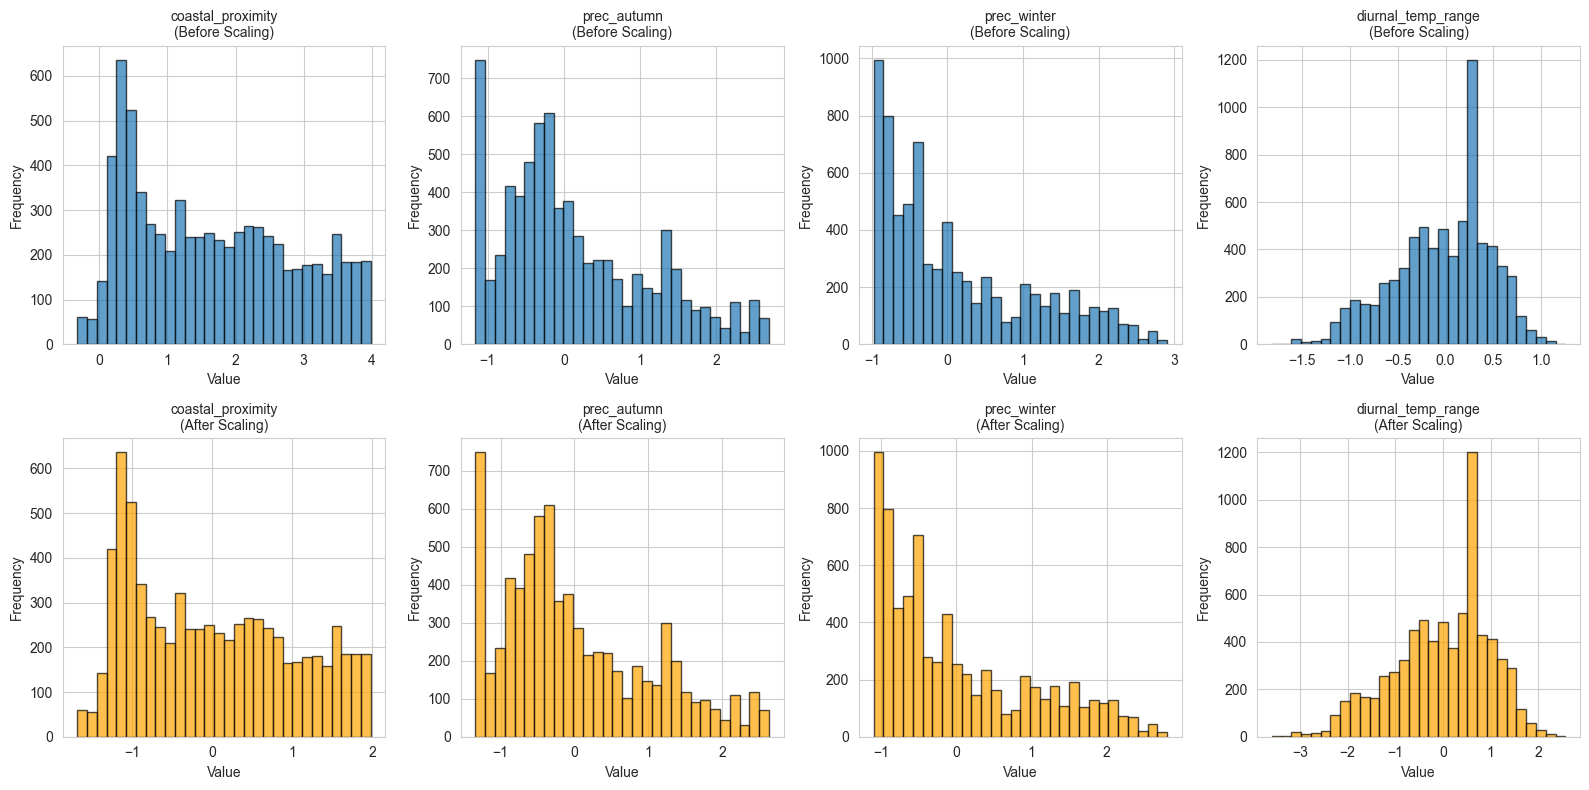

In [ ]:
# Visualize distribution of a few features before and after scaling
sample_features = numerical_X_final.columns[:4].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feature in enumerate(sample_features):
    # Before scaling
    axes[0, idx].hist(numerical_X_final[feature], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, idx].set_title(f'{feature}\n(Before Scaling)', fontsize=10)
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # After scaling
    axes[1, idx].hist(X_scaled_final_df[feature], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1, idx].set_title(f'{feature}\n(After Scaling)', fontsize=10)
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Final Dataset Preparation

Combine scaled features with spatial coordinates for clustering analysis.

In [ ]:
# Combine scaled features with spatial coordinates (for geographic analysis)
final_dataset = pd.concat([
    df_engineered[['longitude', 'latitude']],  # Keep spatial coords
    X_scaled_final_df
], axis=1)

print(f"Final dataset shape: {final_dataset.shape}")
print(f"\nFeatures: {final_dataset.columns.tolist()[:10]} ... (showing first 10)")
print(f"\n✅ Dataset ready for clustering analysis!")
print(f"   Longitude and latitude are preserved for spatial visualization")
print(f"   All features are scaled and ready for distance-based clustering")

Final dataset shape: (7302, 23)

Features: ['longitude', 'latitude', 'class', 'coastal_proximity', 'prec_autumn', 'prec_winter', 'diurnal_temp_range', 'annual_temp_range', 'tmax_summer', 'summer_heat_index'] ... (showing first 10)

Class distribution:
class
0    4017
1    3285
Name: count, dtype: int64

Missing values: 0


In [ ]:
# Display sample of final dataset
print("Sample of final engineered dataset for clustering:\n")
print(final_dataset.head(10))

Sample of final engineered dataset:



,longitude,latitude,class,coastal_proximity,prec_autumn,prec_winter,diurnal_temp_range,annual_temp_range,tmax_summer,summer_heat_index,ph_carbon_interaction,tmin_winter,lat_long_interaction,elevation,ORG_CARBON,TOTAL_N,tmax_spring,tmin_autumn,SAND,fertility_index,roughness,fine_fraction,REF_BULK
0,9.42603,37.00734,1,-1.415336,1.060643,1.485683,-0.679960,-0.528872,-0.456477,-0.503013,1.853548,0.811499,1.326762,-0.130634,0.770050,0.652356,-0.418887,0.465239,0.335059,-0.910698,1.287434,-0.138609,-0.058042
1,4.13116,36.62614,1,-1.090889,2.140176,1.879017,-1.705412,-2.114895,-0.683602,-0.710366,0.815721,0.659969,-0.269060,-0.688964,0.421728,0.531775,-0.504240,0.581918,-1.105160,-0.824610,1.863116,1.058968,0.879096
2,7.28408,36.89190,1,-1.317083,1.256015,1.822987,-1.184838,0.376972,-0.910728,-0.624141,0.785191,1.518642,0.679553,-1.170942,2.502492,1.737583,-0.193311,0.961124,0.224273,-0.289289,-0.339607,-0.253719,-1.346605
3,8.46453,35.31460,0,0.025391,-0.123045,-0.433008,-0.260525,-0.643472,-0.245970,-1.455090,-0.375844,-0.400745,0.923526,0.852408,-0.898228,-0.151516,-0.461564,-0.635917,2.218422,0.128982,0.367103,-1.604714,-1.229463
4,4.65055,36.84538,0,-1.277488,2.262376,1.616814,-2.250162,-0.468243,-1.575486,-1.124195,0.815721,1.278718,-0.107131,-0.416957,0.421728,0.531775,-0.583497,0.866322,-1.105160,-0.824610,1.546363,1.058968,0.879096
5,1.42549,36.16594,0,-0.699202,0.147312,0.091101,0.706392,-0.359171,0.789945,0.893916,0.815721,0.584204,-1.074988,-0.464678,0.421728,0.531775,0.343194,0.261051,-1.105160,-0.824610,0.504083,1.058968,0.879096
6,4.11798,33.48140,0,1.585667,-0.871080,-0.945448,0.997963,1.217202,1.554417,1.471398,-0.896263,-0.255528,-0.377585,0.286920,-0.648445,-0.754420,1.282078,0.202712,0.888989,0.505529,-0.694139,-0.640662,-0.878037
7,-0.17912,35.79881,1,-0.386730,-0.418452,-0.120462,-0.306139,1.069710,-0.871950,-0.012125,1.552692,1.133502,-1.543307,-1.213890,0.770050,0.652356,0.233454,0.443362,0.224273,-0.910698,-0.498528,-0.577274,-0.526610
8,3.07719,36.75280,1,-1.198692,1.657142,1.153059,-1.043591,0.612155,-1.171092,-0.673367,0.948188,1.139815,-0.577789,-1.218662,2.177086,1.335648,-0.278664,0.618380,-0.883588,-0.682743,-0.429327,1.130716,1.699090
9,8.42191,35.53970,0,-0.166196,-0.089096,-0.282036,0.063731,-0.464937,-0.113018,-1.428235,-0.793126,-0.293410,0.926682,0.864338,-0.579697,0.089646,-0.370114,-0.548408,0.224273,-0.251235,-0.386412,-0.126942,-0.526610


In [ ]:
# Save the engineered dataset for clustering
output_path = FIRES_ENGINEERED
final_dataset.to_csv(output_path, index=False)
print(f"✅ Engineered dataset saved to: {output_path}")
print(f"   Shape: {final_dataset.shape}")
print(f"   Ready for KMeans, DBSCAN, and other clustering algorithms")

✅ Engineered dataset saved to: ../results/fires_engineered_features.csv


In [ ]:
# Save feature analysis results (unsupervised)
contributions_df.to_csv(FEATURE_IMPORTANCE_CSV, index=False)
print(f"✅ Feature separation contribution scores saved to: {FEATURE_IMPORTANCE_CSV}")

# Save selected features list
with open(SELECTED_FEATURES_TXT, 'w') as f:
    f.write("Selected Features for Unsupervised Clustering\n")
    f.write("="*60 + "\n\n")
    f.write("Selection Method: Variance-Based + Silhouette Optimization\n")
    f.write("(NO target labels used - purely unsupervised)\n\n")
    f.write("Features:\n")
    for i, feat in enumerate(selected_features, 1):
        f.write(f"{i}. {feat}\n")
print(f"✅ Selected features list saved to: {SELECTED_FEATURES_TXT}")

✅ Feature importance scores saved to: ../results/feature_importance_scores.csv
✅ Selected features list saved to: ../results/selected_features.txt


## 6. Summary

### Feature Engineering Pipeline for UNSUPERVISED Learning (Clustering)

**Key Difference from Supervised Pipeline:**
- ❌ NO target-based selection (no ANOVA, Mutual Information with target, Random Forest)
- ✅ Variance-based selection (high-variance features capture more information)
- ✅ Silhouette analysis (evaluate actual clustering quality)
- ✅ Distance metric analysis (which features separate clusters best)
- ✅ StandardScaler is CRITICAL (distance-based clustering)

---

**1. Feature Extraction:**
- Created 22 new features from domain knowledge
- Climate features: temperature ranges, precipitation patterns, drought indices
- Topography features: terrain complexity, aspect categories, slope interactions
- Soil features: composition ratios, fertility indices, moisture retention
- Spatial features: country indicators, coastal proximity

**2. Categorical Feature Encoding:**
- **TEXTURE_SOTER**: One-hot encoded into binary columns (3 categories → 2 binary columns)
  - TEXTURE_SOTER_F (Fine texture indicator)
  - TEXTURE_SOTER_M (Medium texture indicator)
  - Baseline: TEXTURE_SOTER_C (Coarse texture, when both = 0)
- Binary features compete with numerical features for selection

**3. Feature Selection (Unsupervised Process):**

**Step 1: Remove Multicollinearity (No Target Involved)**
- Identified highly correlated feature pairs (correlation > 0.90)
- For each pair, kept the feature with HIGHER VARIANCE (not target correlation)
- Removed redundant features to reduce multicollinearity

**Step 2: Variance-Based Analysis**
- Analyzed variance distribution across remaining features
- High variance = feature captures more information
- No target labels needed

**Step 3: Silhouette Analysis**
- Evaluated different feature subsets using KMeans clustering quality
- Tested 5, 10, 15, 20, and all remaining features
- Selected number of features that maximizes Silhouette Score
- Silhouette Score: measures cluster cohesion and separation (−1 to +1)

**Step 4: PCA Analysis (Optional)**
- Decomposed features into principal components
- Identified how many components needed for 85% variance
- Useful for visualization in 2D/3D space

**Step 5: Distance Metric Analysis**
- Calculated which features contribute most to cluster separation
- Used separation ratio = between-cluster variance / within-cluster variance
- Features with high ratios help clusters differentiate better

**4. Feature Scaling:**
- Applied StandardScaler for Z-score normalization
- **CRITICAL for clustering**: Distance metrics (Euclidean, Manhattan) are scale-sensitive
- Without scaling, features with large ranges dominate clustering results
- All features now have mean ≈ 0 and standard deviation ≈ 1

**Final Output:**
- Engineered dataset: N rows × (2 coordinates + selected features) columns
- Longitude and latitude preserved for spatial analysis
- All features scaled and ready for clustering models
- No missing values
- No multicollinearity issues
- **Purely unsupervised**: no target variable involved in selection

In [ ]:
print("\n" + "="*80)
print("UNSUPERVISED FEATURE ENGINEERING COMPLETE")
print("="*80)
print(f"\n📊 Original dataset: {df.shape[0]} rows × {df.shape[1]} features")
print(f"📊 Final dataset: {final_dataset.shape[0]} rows × {final_dataset.shape[1]} columns")
print(f"\n✅ Feature Extraction: Created 22 new domain-specific features")
print(f"✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER")
print(f"✅ Feature Selection (Unsupervised):")
print(f"     - Multicollinearity removal based on VARIANCE (r > 0.90, keep high-variance)")
print(f"     - Silhouette analysis to evaluate clustering quality")
print(f"     - Distance metric analysis for feature contributions")
print(f"     - PCA analysis for variance explanation")
print(f"\n✅ Feature Scaling: StandardScaler (CRITICAL for distance-based clustering)")
print(f"     - All features have mean ≈ 0, std ≈ 1")
print(f"     - Ensures fair distance calculations")

# Check if one-hot features made it
one_hot_final = [col for col in selected_features if col.startswith('TEXTURE_SOTER_')]
if one_hot_final:
    print(f"\n✅ One-hot features in final selection: {one_hot_final}")
else:
    print(f"\n⚠ No one-hot features in final selection (high variance threshold)")

print(f"\n📁 Output file: {output_path}")
print(f"📊 Selected {len(selected_features)} features (from {X.shape[1]} initial)")
print(f"\n🎯 Dataset is ready for clustering models!")
print(f"   → KMeans, DBSCAN, Agglomerative Clustering, etc.")
print(f"   → Longitude/Latitude preserved for spatial visualization")
print("="*80)


FEATURE ENGINEERING COMPLETE

📊 Original dataset: 7302 rows × 42 features
📊 Final dataset: 7302 rows × 23 columns

✅ Feature Extraction: Created 22 new domain-specific features
✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER (created binary features)
✅ Feature Selection: Selected top 20 most predictive features
     - Multicollinearity removal (r > 0.90)
     - Target correlation ranking (top 30)
     - Composite scoring: ANOVA + MI + RF (top 20)
✅ No one-hot features in final selection
     (Categorical feature had lower predictive power)
✅ Feature Scaling: StandardScaler applied (all features normalized)

📁 Output file: ../results/fires_engineered_features.csv

🎯 Dataset is ready for model training!
